🤖 Machine Learning &nbsp;·&nbsp; *Bài 22/23*

[« Machine Learning - Cross Validation](021_ml_cross_validation.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - K-nearest neighbors (KNN) »](023_ml_k_nearest_neighbors.ipynb)

# Machine Learning - AUC - ROC Curve

> 📖 **Học song song trên W3Schools:** [python_ml_auc_roc.asp](https://www.w3schools.com/python/python_ml_auc_roc.asp)
>
> 🎯 **Trong bài này:** AUC - ROC Curve · Imbalanced Data · Probabilities

## AUC - ROC Curve

Trong phân loại, có nhiều chỉ số đánh giá. Phổ biến nhất là **accuracy** — tỉ lệ dự đoán đúng. Nhưng accuracy có thể **gây hiểu nhầm**: với dữ liệu **mất cân bằng**, mô hình chỉ cần luôn đoán lớp đa số là đã có accuracy cao.

**AUC - ROC curve** là một chỉ số khác:

- **ROC** (*Receiver Operating Characteristic*) là đường cong vẽ **tỉ lệ dương tính thật (TPR)** theo **tỉ lệ dương tính giả (FPR)** ở các ngưỡng phân loại khác nhau.
- **AUC** (*Area Under the Curve*) là **diện tích dưới đường ROC** — thể hiện khả năng mô hình **phân biệt** các lớp. AUC càng gần 1 càng tốt; 0.5 tương đương đoán ngẫu nhiên.

## Imbalanced Data — Dữ liệu mất cân bằng

Giả sử có dữ liệu mất cân bằng: phần lớn thuộc lớp **0**, chỉ ~5% thuộc lớp **1**:

In [1]:
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

n = 10000
ratio = .95
n_0 = int((1 - ratio) * n)
n_1 = int(ratio * n)

y = np.array([0] * n_0 + [1] * n_1)
# xác suất dự đoán của mô hình giả định 1: luôn dự đoán lớp 1
y_proba = np.array([1] * n)
y_pred = y_proba > .5

print(f'accuracy score: {accuracy_score(y, y_pred)}')
cf_mat = confusion_matrix(y, y_pred)
print('Confusion matrix')
print(cf_mat)
print(f'class 0 accuracy: {cf_mat[0][0] / n_0}')
print(f'class 1 accuracy: {cf_mat[1][1] / n_1}')

accuracy score: 0.95
Confusion matrix
[[   0  500]
 [   0 9500]]
class 0 accuracy: 0.0
class 1 accuracy: 1.0


Accuracy rất cao, nhưng mô hình **không dự đoán đúng bất kỳ mẫu lớp 0 nào**!

So sánh với mô hình 2 — dự đoán **có phân biệt** hai lớp:

In [2]:
np.random.seed(0)
# mô hình giả định 2
y_proba_2 = np.array(
    np.random.uniform(0, .7, n_0).tolist() +
    np.random.uniform(.3, 1, n_1).tolist()
)
y_pred_2 = y_proba_2 > .5

print(f'accuracy score: {accuracy_score(y, y_pred_2)}')
cf_mat = confusion_matrix(y, y_pred_2)
print('Confusion matrix')
print(cf_mat)
print(f'class 0 accuracy: {cf_mat[0][0] / n_0}')
print(f'class 1 accuracy: {cf_mat[1][1] / n_1}')

accuracy score: 0.7105
Confusion matrix
[[ 364  136]
 [2759 6741]]
class 0 accuracy: 0.728
class 1 accuracy: 0.7095789473684211


Accuracy của mô hình 2 **thấp hơn**, nhưng nó dự đoán **tốt cả hai lớp** — hữu ích hơn nhiều. Accuracy không phản ánh điều này, nhưng **AUC** thì có.

Vẽ ROC và tính AUC cho cả hai mô hình:

model 1 AUC score: 0.5


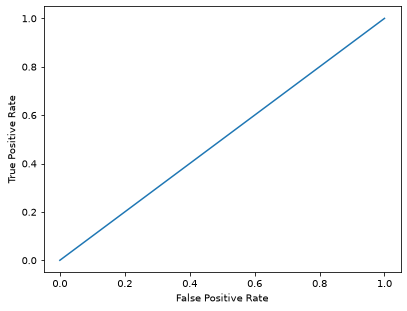

In [3]:
import matplotlib.pyplot as plt

def plot_roc_curve(true_y, y_prob):
    fpr, tpr, thresholds = roc_curve(true_y, y_prob)
    plt.plot(fpr, tpr)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

plot_roc_curve(y, y_proba)
print(f'model 1 AUC score: {roc_auc_score(y, y_proba)}')
plt.show()

model 2 AUC score: 0.8356141052631578


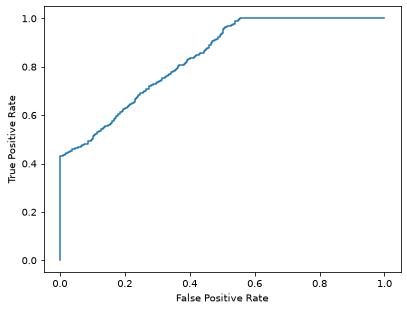

In [4]:
plot_roc_curve(y, y_proba_2)
print(f'model 2 AUC score: {roc_auc_score(y, y_proba_2)}')
plt.show()

AUC của mô hình 1 là **0.5** (không hơn đoán ngẫu nhiên), mô hình 2 cao hơn nhiều → mô hình 2 **phân biệt lớp tốt hơn**.

## Probabilities — Xác suất

AUC đánh giá dựa trên **xác suất** dự đoán chứ không chỉ nhãn cuối cùng. Hai mô hình có thể có **cùng accuracy** nhưng AUC khác nhau — mô hình **tự tin hơn** khi đúng sẽ có AUC cao hơn:

In [5]:
n = 10000
y = np.array([0] * n + [1] * n)

np.random.seed(0)
y_prob_1 = np.array(
    np.random.uniform(.25, .5, n // 2).tolist() +
    np.random.uniform(.3, .7, n).tolist() +
    np.random.uniform(.5, .75, n // 2).tolist()
)
y_prob_2 = np.array(
    np.random.uniform(0, .4, n // 2).tolist() +
    np.random.uniform(.3, .7, n).tolist() +
    np.random.uniform(.6, 1, n // 2).tolist()
)

print(f'model 1 accuracy score: {accuracy_score(y, y_prob_1 > .5)}')
print(f'model 2 accuracy score: {accuracy_score(y, y_prob_2 > .5)}')

print(f'model 1 AUC score: {roc_auc_score(y, y_prob_1)}')
print(f'model 2 AUC score: {roc_auc_score(y, y_prob_2)}')

model 1 accuracy score: 0.74775
model 2 accuracy score: 0.7455
model 1 AUC score: 0.77269991
model 2 AUC score: 0.85867003


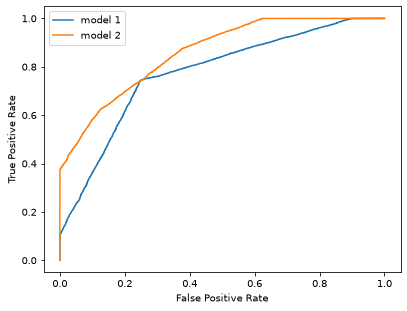

In [6]:
plot_roc_curve(y, y_prob_1)
plot_roc_curve(y, y_prob_2)
plt.legend(["model 1", "model 2"])
plt.show()

---

## 🧠 Ghi nhớ nhanh

> - ⚠️ Accuracy dễ **đánh lừa** với dữ liệu mất cân bằng.
> - **ROC** = TPR theo FPR ở mọi ngưỡng; **AUC** = diện tích dưới ROC (0.5 = ngẫu nhiên, 1 = hoàn hảo).
> - `roc_curve(y, y_prob)` · `roc_auc_score(y, y_prob)` — dùng **xác suất**, không phải nhãn.

---

## 📝 Exercise — Bài tập nhanh

**❓ Câu hỏi:** AUC bằng **0.5** nghĩa là gì?

- **A.** Mô hình hoàn hảo
- **B.** Mô hình đúng 50 mẫu
- **C.** Mô hình sai hoàn toàn
- **D.** Mô hình không hơn đoán ngẫu nhiên

<details>
<summary>👉 Xem đáp án</summary>

✅ **Đáp án: D** — Mô hình không hơn đoán ngẫu nhiên

</details>

---

[« Machine Learning - Cross Validation](021_ml_cross_validation.ipynb) &nbsp;•&nbsp; [📚 Mục lục](../README.md) &nbsp;•&nbsp; [Machine Learning - K-nearest neighbors (KNN) »](023_ml_k_nearest_neighbors.ipynb)